# Financial Document Classification — BERT vs FinBERT Ablation Study
## BERT vs Three FinBERT Variants

**Authors:** Aaathmika Krishna · Neha Verma · Gaurav Arora  
**University of North Carolina Charlotte · 2026**

---

### Notebook Structure

| Section | Description | Re-runnable? |
|---------|-------------|--------------|
| 0 — Setup | Installs, imports, config | Always run first |
| 1 — Preprocessing | HTML parsing, augmentation, cache | Run once |
| 1B — Shared Utilities | Dataset, FocalLoss, train/eval functions | Always run after Section 0 |
| 2 — BERT Baseline | bert-base-uncased + aug | Skip if checkpoint exists |
| 3 — BERT Evaluation | Load → evaluate | ✅ Re-run anytime |
| 4A — FinBERT + Aug | Standard fine-tuning | Skip if checkpoint exists |
| 4B — FinBERT + Aug + Unfreezing | Top-4 layer unfreezing | Skip if checkpoint exists |
| 4C — FinBERT + Aug + Mean Pooling | Mean pooling instead of [CLS] | Skip if checkpoint exists |
| 5 — FinBERT Evaluations | Load each checkpoint → evaluate | ✅ Re-run anytime |
| 6 — Full Comparison | BERT + 3 FinBERT variants side by side | ✅ Re-run anytime |
| 7 — KPI Extraction | Regex metric extractors | ✅ Re-run anytime |
| 8 — Gradio Demo | Interactive UI (uses best model) | ✅ Re-run anytime |
| 9 — Visualizations & Error Analysis | Training curves, confusion matrix, error flags | ✅ Re-run anytime |

> **Key design principle:** All three FinBERT variants train on identical augmented data.  
> The only variable changing is the model architecture / training strategy.


## Section 0 — Setup
*Run once per Colab session.*

In [1]:
# ── Installs ──────────────────────────────────────────────────
!pip install transformers torch scikit-learn beautifulsoup4 tqdm gradio kaggle -q

# ── Imports ───────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from bs4 import BeautifulSoup
from tqdm import tqdm
import numpy as np
import os, re, random, json, zipfile, shutil, tempfile, subprocess
import pandas as pd

# ── Mount Drive ───────────────────────────────────────────────
from google.colab import drive, files
drive.mount('/content/drive')

# ── Device ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Paths ─────────────────────────────────────────────────────
DATA_DIR              = '/content/financial_data'
BERT_CKPT             = '/content/drive/MyDrive/checkpoints/bert_baseline.pt'
FINBERT_AUG_CKPT      = '/content/drive/MyDrive/checkpoints/finbert_aug.pt'
FINBERT_UNFREEZE_CKPT = '/content/drive/MyDrive/checkpoints/finbert_unfreeze.pt'
FINBERT_POOL_CKPT     = '/content/drive/MyDrive/checkpoints/finbert_pool.pt'
DATA_CACHE            = '/content/drive/MyDrive/checkpoints/preprocessed_data.json'
os.makedirs('/content/drive/MyDrive/checkpoints', exist_ok=True)

# ── Config ────────────────────────────────────────────────────
LABEL_MAP          = {'Income Statement':0,'Balance Sheets':1,'Cash Flow':2,'Notes':3,'Others':4}
LABEL_NAMES        = list(LABEL_MAP.keys())
NUM_CLASSES        = 5
MAX_LENGTH         = 512
BATCH_SIZE         = 4
RANDOM_SEED        = 42
TARGET_CF          = 200
BERT_MODEL_NAME    = 'bert-base-uncased'
FINBERT_MODEL_NAME = 'yiyanghkust/finbert-pretrain'
BERT_EPOCHS        = 6
FINBERT_EPOCHS     = 6
BERT_LR            = 1e-5
FINBERT_LR         = 1e-5
UNFREEZE_LAYERS    = [8, 9, 10, 11]   # top 4 transformer layers

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── Download Dataset from Kaggle ──────────────────────────────
if not os.path.exists(DATA_DIR) or not os.listdir(DATA_DIR):
    print("Upload your kaggle.json file:")
    files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    os.makedirs(DATA_DIR, exist_ok=True)
    with tempfile.TemporaryDirectory() as tmp:
        subprocess.run(['kaggle','datasets','download',
                        '-d','drcrabkg/financial-statements-clustering','-p',tmp], check=True)
        zip_file = next(f for f in os.listdir(tmp) if f.endswith('.zip'))
        with zipfile.ZipFile(os.path.join(tmp, zip_file)) as z:
            z.extractall(tmp)
        for item in os.listdir(tmp):
            src = os.path.join(tmp, item)
            if os.path.isdir(src):
                for sub in os.listdir(src):
                    s, d = os.path.join(src, sub), os.path.join(DATA_DIR, sub)
                    if os.path.isdir(s): shutil.move(s, d)
    print(f"Dataset ready: {sorted(os.listdir(DATA_DIR))}")
else:
    print(f"Dataset already present: {sorted(os.listdir(DATA_DIR))}")

print("Setup complete.")


Mounted at /content/drive
Device: cuda
Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset ready: ['Balance Sheets', 'Cash Flow', 'Income Statement', 'Notes', 'Others']
Setup complete.


## Section 1 — Preprocessing & Augmentation
*Run once. Cached to Drive. All models use identical splits.*

**Augmentation (same for all models):**
- Cash Flow: 36 → 200 samples
- 15-term financial synonym dictionary
- 1–3 synonym swaps per sample
- Token swaps: `[NUMBER]→[AMOUNT]`, `[DATE]→[PERIOD]`
- Structural variants via `make_incomplete()` (5 strategies)


In [2]:
# ── HTML Preprocessing ────────────────────────────────────────
def preprocess_html(html_content):
    soup = BeautifulSoup(html_content, 'html.parser')
    for tag in soup(["script", "style"]):
        tag.decompose()

    parts = []
    seen_snippets = set()

    def add_part(prefix, text, max_len=None):
        text = re.sub(r'\s+', ' ', text).strip()
        if max_len is not None:
            text = text[:max_len]
        if len(text) < 4:
            return
        key = text.lower()
        if key not in seen_snippets:
            seen_snippets.add(key)
            parts.append(f"{prefix} {text}")

    for table in soup.find_all('table'):
        add_part("[TABLE]", table.get_text(separator=' | ', strip=True))

    for h in ['h1', 'h2', 'h3', 'h4', 'h5', 'h6']:
        for header in soup.find_all(h):
            add_part("[HEADER]", header.get_text(strip=True))

    for elem in soup.find_all(attrs={"class": re.compile(r"cash|flow|statement|income|balance", re.I)})[:3]:
        add_part("[FINANCIAL_ELEMENT]", elem.get_text(strip=True), max_len=100)

    remaining = re.sub(r'\s+', ' ', soup.get_text(separator=' ', strip=True))
    remaining = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', '[DATE]', remaining)
    remaining = re.sub(r'\$[\d,]+\.?\d*', '[CURRENCY]', remaining)
    remaining = re.sub(r'\b\d{1,3}(?:,\d{3})+\b', '[NUMBER]', remaining)

    structured_only = ' '.join(parts).strip()
    if structured_only:
        # Reduce exact duplication of extracted snippets in the appended raw text.
        dedup_pattern = re.escape(structured_only[:500])
        remaining = re.sub(dedup_pattern, ' ', remaining, flags=re.IGNORECASE)
        remaining = re.sub(r'\s+', ' ', remaining).strip()

    final_text = ' '.join([p for p in [structured_only, remaining] if p]).strip()
    return final_text

def load_documents(data_dir):
    records = []
    for name, label_id in LABEL_MAP.items():
        folder = os.path.join(data_dir, name)
        if not os.path.exists(folder):
            continue
        files_list = sorted([f for f in os.listdir(folder) if f.endswith('.html')])
        print(f"  {name}: {len(files_list)} files")
        for filename in files_list:
            file_path = os.path.join(folder, filename)
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    text = preprocess_html(f.read())
                if text.strip():
                    records.append({
                        'doc_id': f"{name}/{filename}",
                        'label': label_id,
                        'label_name': name,
                        'text': text,
                        'source_path': file_path,
                    })
            except Exception as e:
                print(f"    Error {filename}: {e}")
    print(f"Total loaded: {len(records)}")
    return records

print("Loading documents...")
records = load_documents(DATA_DIR)

print("\nClass distribution (original):")
dist = Counter(r['label'] for r in records)
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name}: {dist[i]}")


Loading documents...
  Income Statement: 317 files
  Balance Sheets: 282 files
  Cash Flow: 36 files
  Notes: 702 files
  Others: 1236 files
Total loaded: 2573

Class distribution (original):
  Income Statement: 317
  Balance Sheets: 282
  Cash Flow: 36
  Notes: 702
  Others: 1236


In [3]:
# ── Safe Training-Only Augmentation ───────────────────────────
# Note:
# - Splits are created on ORIGINAL documents first to prevent leakage.
# - Augmentation is applied to TRAIN ONLY.
# - Augmentation is lexical/paraphrastic only; no class-unique synthetic marker tokens.

FINANCIAL_SYNONYMS = {
    'operating activities':  ['operational activities', 'cash generating activities'],
    'investing activities':  ['investment activities', 'capital investment activities'],
    'financing activities':  ['funding activities', 'capital financing activities'],
    'cash provided by':      ['cash generated from', 'cash received from'],
    'cash used in':          ['cash applied to', 'cash spent on'],
    'net income':            ['net profit', 'net earnings'],
    'revenue':               ['net sales', 'total revenue', 'net revenue'],
    'total assets':          ['aggregate assets', 'total asset base'],
    'shareholders equity':   ['stockholders equity', 'owners equity'],
    'total liabilities':     ['total obligations', 'aggregate liabilities'],
    'earnings per share':    ['EPS', 'profit per share'],
    'capital expenditure':   ['capex', 'capital spending'],
    'depreciation':          ['amortisation', 'depreciation and amortisation'],
    'profit before tax':     ['pre-tax profit', 'income before tax'],
    'cash equivalents':      ['near-cash assets', 'short-term liquid assets'],
}

def synonym_augment(text):
    aug = text
    n_swaps = random.randint(1, 3)
    terms = random.sample(list(FINANCIAL_SYNONYMS.keys()), min(n_swaps, len(FINANCIAL_SYNONYMS)))
    for term in terms:
        if term.lower() in aug.lower():
            replacement = random.choice(FINANCIAL_SYNONYMS[term])
            aug = re.sub(re.escape(term), replacement, aug, count=1, flags=re.IGNORECASE)
    return aug

def augment_cash_flow_train_records(train_records, target_cf=200):
    train_aug = [dict(r) for r in train_records]
    cf_records = [r for r in train_records if r['label'] == LABEL_MAP['Cash Flow']]
    original_cf = len(cf_records)
    print(f"Cash Flow in TRAIN before augmentation: {original_cf} → target: {target_cf}")

    if original_cf == 0:
        print("No Cash Flow documents found in training split; skipping augmentation.")
        return train_aug

    existing_texts = set(r['text'] for r in train_aug)
    current_cf = original_cf
    attempts = 0
    max_attempts = max(target_cf * 20, 1000)

    while current_cf < target_cf and attempts < max_attempts:
        base = random.choice(cf_records)
        aug_text = synonym_augment(base['text'])

        # Occasionally apply a second lexical augmentation pass for extra variation.
        if random.random() < 0.30:
            aug_text = synonym_augment(aug_text)

        if aug_text != base['text'] and aug_text not in existing_texts:
            new_record = dict(base)
            new_record['doc_id'] = f"{base['doc_id']}__aug_{current_cf+1}"
            new_record['text'] = aug_text
            new_record['is_augmented'] = True
            train_aug.append(new_record)
            existing_texts.add(aug_text)
            current_cf += 1
        attempts += 1

    print(f"Cash Flow in TRAIN after augmentation: {sum(1 for r in train_aug if r['label'] == LABEL_MAP['Cash Flow'])}")
    return train_aug


In [17]:
# ── Create Leakage-Safe Splits & Cache ────────────────────────
# Split ORIGINAL documents first, then augment TRAIN only.

all_labels = [r['label'] for r in records]
train_records, test_records = train_test_split(
    records,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=all_labels
)

train_labels = [r['label'] for r in train_records]
train_records, val_records = train_test_split(
    train_records,
    test_size=0.125,   # 0.125 of 0.8 = 0.1 overall
    random_state=RANDOM_SEED,
    stratify=train_labels
)

print("Original split sizes (before augmentation)")
print(f"Train originals : {len(train_records)}")
print(f"Val originals   : {len(val_records)}")
print(f"Test originals  : {len(test_records)}")

train_records_aug = augment_cash_flow_train_records(train_records, target_cf=TARGET_CF)

X_train = [r['text'] for r in train_records_aug]
y_train = [r['label'] for r in train_records_aug]

X_val = [r['text'] for r in val_records]
y_val = [r['label'] for r in val_records]

X_test = [r['text'] for r in test_records]
y_test = [r['label'] for r in test_records]

print(f"\nFinal split sizes (after train-only augmentation)")
print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

print("\nClass distribution:")
for split_name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = Counter(ys)
    print(f"  {split_name}:")
    for i, name in enumerate(LABEL_NAMES):
        print(f"    {name}: {dist[i]}")

class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(y_train), y=y_train),
    dtype=torch.float
)
print("\nClass weights (computed from TRAIN only):")
for i, (name, w) in enumerate(zip(LABEL_NAMES, class_weights)):
    print(f"  {name}: {w:.4f}")

cache = {
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
    'class_weights': class_weights.tolist(),
    'train_doc_ids': [r['doc_id'] for r in train_records_aug],
    'val_doc_ids': [r['doc_id'] for r in val_records],
    'test_doc_ids': [r['doc_id'] for r in test_records],
    'notes': {
        'split_strategy': 'split originals first, augment train only',
        'augmentation': 'cash-flow lexical augmentation only, no synthetic marker tokens'
    }
}
with open(DATA_CACHE, 'w') as f:
    json.dump(cache, f)

print(f"\nCached to {DATA_CACHE}")
print("All models will use these identical leakage-safe splits.")


Original split sizes (before augmentation)
Train originals : 1800
Val originals   : 258
Test originals  : 515
Cash Flow in TRAIN before augmentation: 25 → target: 200
Cash Flow in TRAIN after augmentation: 200

Final split sizes (after train-only augmentation)
Train : 1975 | Val : 258 | Test : 515

Class distribution:
  Train:
    Income Statement: 221
    Balance Sheets: 198
    Cash Flow: 200
    Notes: 491
    Others: 865
  Val:
    Income Statement: 32
    Balance Sheets: 28
    Cash Flow: 4
    Notes: 70
    Others: 124
  Test:
    Income Statement: 64
    Balance Sheets: 56
    Cash Flow: 7
    Notes: 141
    Others: 247

Class weights (computed from TRAIN only):
  Income Statement: 1.7873
  Balance Sheets: 1.9949
  Cash Flow: 1.9750
  Notes: 0.8045
  Others: 0.4566

Cached to /content/drive/MyDrive/checkpoints/preprocessed_data.json
All models will use these identical leakage-safe splits.


## Section 1B — Shared Utilities
*Run after Section 0. Defines all shared classes and functions.*

In [9]:
# ── Load Cached Data (skip Section 1 if cache exists) ─────────
if os.path.exists(DATA_CACHE):
    with open(DATA_CACHE, 'r') as f:
        cache = json.load(f)
    X_train = cache['X_train']; y_train = cache['y_train']
    X_val   = cache['X_val'];   y_val   = cache['y_val']
    X_test  = cache['X_test'];  y_test  = cache['y_test']
    class_weights = torch.tensor(cache['class_weights'], dtype=torch.float)
    test_records = [
        {'text': text, 'label': label, 'label_name': LABEL_NAMES[label], 'doc_id': doc_id}
        for text, label, doc_id in zip(
            X_test, y_test,
            cache.get('test_doc_ids', [''] * len(X_test))
        )
    ]
    print(f"Loaded cached splits — Train:{len(X_train)} Val:{len(X_val)} Test:{len(X_test)}")
    if 'notes' in cache:
        print("Cache notes:", cache['notes'])
else:
    print("No cache found — run Section 1 first.")

# ── Dataset ───────────────────────────────────────────────────
class FinancialDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts, self.labels, self.tokenizer, self.max_length = texts, labels, tokenizer, max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def make_loaders(tokenizer, max_length=512, batch_size=4):
    return (
        DataLoader(FinancialDataset(X_train, y_train, tokenizer, max_length), batch_size=batch_size, shuffle=True),
        DataLoader(FinancialDataset(X_val,   y_val,   tokenizer, max_length), batch_size=batch_size),
        DataLoader(FinancialDataset(X_test,  y_test,  tokenizer, max_length), batch_size=batch_size)
    )

# ── Focal Loss ────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.alpha, self.gamma, self.weight = alpha, gamma, weight

    def forward(self, inputs, targets):
        ce = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce)
        return (self.alpha * (1 - pt) ** self.gamma * ce).mean()

# ── Evaluation ────────────────────────────────────────────────
def evaluate_model(model, loader, device, loss_fn=None):
    model.eval()
    preds, trues, total_loss = [], [], 0.0
    with torch.no_grad():
        for batch in loader:
            out = model(
                batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            if loss_fn is not None:
                loss = loss_fn(out.logits, batch['labels'].to(device))
                total_loss += loss.item()
            preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            trues.extend(batch['labels'].numpy())

    acc = np.mean(np.array(preds) == np.array(trues))
    recalls = recall_score(trues, preds, labels=list(range(NUM_CLASSES)), average=None, zero_division=0)
    macro_f1 = f1_score(trues, preds, average='macro', zero_division=0)
    avg_loss = total_loss / len(loader) if loss_fn is not None else None
    return acc, avg_loss, recalls, macro_f1

# ── Training Loop ─────────────────────────────────────────────
def train_model(model, train_loader, val_loader, device, epochs, lr, class_weights, save_path):
    loss_fn = FocalLoss(alpha=1, gamma=2, weight=class_weights.to(device))
    optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    model.to(device)
    best_metric = -1.0
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad()
            out = model(
                batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            loss = loss_fn(out.logits, batch['labels'].to(device))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)
        val_acc, val_loss, recalls, val_macro_f1 = evaluate_model(model, val_loader, device, loss_fn=loss_fn)
        cf_recall = recalls[LABEL_MAP['Cash Flow']]

        epoch_metrics = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_macro_f1': val_macro_f1,
            'cf_recall': cf_recall
        }
        history.append(epoch_metrics)

        print(
            f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | Val Macro F1: {val_macro_f1:.4f} | CF Recall: {cf_recall:.4f}"
        )

        # Primary checkpoint criterion: validation macro F1.
        # Tie-breakers: validation accuracy, then Cash Flow recall.
        ranking_key = (val_macro_f1, val_acc, cf_recall)
        if ranking_key > best_metric if isinstance(best_metric, tuple) else ranking_key > (-1, -1, -1):
            best_metric = ranking_key
            torch.save({
                'model_state_dict': model.state_dict(),
                'best_epoch': epoch + 1,
                'selection_metric': 'val_macro_f1_then_val_acc_then_cf_recall',
                'val_accuracy': val_acc,
                'val_macro_f1': val_macro_f1,
                'cf_recall': cf_recall,
                'history': history
            }, save_path)
            print(
                f"  ✓ Saved checkpoint at epoch {epoch+1} "
                f"(val_macro_f1={val_macro_f1:.4f}, val_acc={val_acc:.4f}, cf_recall={cf_recall:.4f})"
            )

    print("Training complete.")
    print(f"Best checkpoint criterion (macro_f1, acc, cf_recall): {best_metric}")
    return model, history

def full_evaluation(model, loader, device, model_name="Model", return_logits=False):
    model.eval()
    preds, trues = [], []
    all_logits = []

    with torch.no_grad():
        for batch in loader:
            out = model(
                batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )

            logits = out.logits
            batch_preds = torch.argmax(logits, dim=1).cpu().numpy()

            preds.extend(batch_preds)
            trues.extend(batch['labels'].numpy())

            if return_logits:
                all_logits.append(logits.cpu().numpy())

    print(f"\n{'='*60}\n{model_name} — TEST SET RESULTS\n{'='*60}")
    print(classification_report(trues, preds, target_names=LABEL_NAMES, digits=4))
    print("CONFUSION MATRIX")
    print(confusion_matrix(trues, preds))

    if return_logits:
        all_logits = np.vstack(all_logits)
        return preds, trues, all_logits

    return preds, trues

# ════════════════════════════════════════════════════════════
# MODEL VARIANTS
# ════════════════════════════════════════════════════════════

# ── Variant A: Standard FinBERT (BertForSequenceClassification) ──
# Uses default [CLS] token pooling — loaded directly from HuggingFace

# ── Variant B: FinBERT + Layer Unfreezing ─────────────────────
def apply_layer_unfreezing(model, unfreeze_layers=UNFREEZE_LAYERS):
    for param in model.parameters():
        param.requires_grad = False
    for layer_idx in unfreeze_layers:
        for param in model.bert.encoder.layer[layer_idx].parameters():
            param.requires_grad = True
    for param in model.bert.pooler.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Layer unfreezing applied — trainable: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")
    return model

# ── Variant C: FinBERT + Masked Mean Pooling ──────────────────
class FinBERTWithMeanPooling(nn.Module):
    """
    Masked mean-pools all token outputs instead of using [CLS] only.
    This is mean pooling, not attention pooling.
    """
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        token_embs = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (token_embs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        class Output:
            def __init__(self, logits, loss):
                self.logits = logits
                self.loss = loss

        return Output(logits, loss)

def get_confidence_from_logits(logits):
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    return np.max(probs, axis=1)

def review_summary_from_preds(trues, preds, confidences, model_name, threshold=0.95):
    import numpy as np
    import pandas as pd

    trues = np.array(trues)
    preds = np.array(preds)
    confidences = np.array(confidences)

    results = pd.DataFrame({
        "true_label": trues,
        "pred_label": preds,
        "confidence": confidences
    })

    # flag logic
    results["flag_review"] = results["confidence"] < threshold
    results["is_wrong"] = results["true_label"] != results["pred_label"]

    total = len(results)
    flagged = results["flag_review"].sum()
    passed = total - flagged

    wrong_total = results["is_wrong"].sum()
    wrong_flagged = results.loc[results["flag_review"], "is_wrong"].sum()
    wrong_passed = results.loc[~results["flag_review"], "is_wrong"].sum()

    print("\n" + "="*70)
    print(f"{model_name} — REVIEW SUMMARY @ {int(threshold*100)}% confidence")
    print("="*70)
    print(f"Total rows              : {total}")
    print(f"Auto-pass rows          : {passed}")
    print(f"Flagged for review      : {flagged} ({flagged/total:.2%})")
    print(f"Total wrong predictions : {wrong_total}")
    print(f"Wrong + flagged         : {wrong_flagged}")
    print(f"Wrong + auto-passed     : {wrong_passed}")

    if flagged > 0:
        print(f"Error rate within flagged: {wrong_flagged/flagged:.2%}")
    if passed > 0:
        print(f"Error rate within passed : {wrong_passed/passed:.2%}")

    print("\nSample flagged rows:")
    print(results[results["flag_review"]].head(10))

    return results

def is_income_like(text):
    text = str(text).lower()

    keywords = [
        "revenue",
        "total revenue",
        "turnover",
        "ebitda",
        "ebit",
        "profit before tax",
        "pbt",
        "profit after tax",
        "pat",
        "net income",
        "total comprehensive income"
    ]

    hits = sum(1 for kw in keywords if kw in text)
    return hits >= 3

print("All model variants defined.")
print("  Variant A: Standard FinBERT (BertForSequenceClassification)")
print("  Variant B: FinBERT + Layer Unfreezing (top 4 layers)")
print("  Variant C: FinBERT + Masked Mean Pooling")
print("Shared utilities ready.")

Loaded cached splits — Train:1975 Val:258 Test:515
Cache notes: {'split_strategy': 'split originals first, augment train only', 'augmentation': 'cash-flow lexical augmentation only, no synthetic marker tokens'}
All model variants defined.
  Variant A: Standard FinBERT (BertForSequenceClassification)
  Variant B: FinBERT + Layer Unfreezing (top 4 layers)
  Variant C: FinBERT + Masked Mean Pooling
Shared utilities ready.


## Section 2 — BERT Baseline Training
*Skip if `bert_baseline.pt` exists in Drive.*

In [ ]:
if os.path.exists(BERT_CKPT):
    print(f"Checkpoint found at {BERT_CKPT} — skip to Section 3.")
else:
    print(f"Training BERT baseline — {BERT_MODEL_NAME} | epochs={BERT_EPOCHS} | lr={BERT_LR}")


Checkpoint found at /content/drive/MyDrive/checkpoints/bert_baseline.pt — skip to Section 3.


In [ ]:
# ── BERT TRAINING ─────────────────────────────────────────────
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model     = BertForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=NUM_CLASSES)

train_loader, val_loader, _ = make_loaders(bert_tokenizer, MAX_LENGTH, BATCH_SIZE)
print(f"Batches — Train:{len(train_loader)} Val:{len(val_loader)}")

bert_model, bert_history = train_model(
    bert_model,
    train_loader,
    val_loader,
    device,
    epochs=BERT_EPOCHS,
    lr=BERT_LR,
    class_weights=class_weights,
    save_path=BERT_CKPT
)
print(f"BERT training complete. Saved to {BERT_CKPT}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Batches — Train:494 Val:65


Epoch 1/6: 100%|██████████| 494/494 [04:03<00:00,  2.03it/s]


  Train Loss: 0.5410 | Val Loss: 0.0600 | Val Acc: 0.9109 | Val Macro F1: 0.9351 | CF Recall: 1.0000
  ✓ Saved checkpoint at epoch 1 (val_macro_f1=0.9351, val_acc=0.9109, cf_recall=1.0000)


...

  Train Loss: 0.0236 | Val Loss: 0.0220 | Val Acc: 0.9612 | Val Macro F1: 0.9681 | CF Recall: 1.0000
  ✓ Saved checkpoint at epoch 4 (val_macro_f1=0.9681, val_acc=0.9612, cf_recall=1.0000)


Epoch 5/6: 100%|██████████| 494/494 [04:00<00:00,  2.05it/s]


  Train Loss: 0.0161 | Val Loss: 0.0258 | Val Acc: 0.9729 | Val Macro F1: 0.9728 | CF Recall: 1.0000
  ✓ Saved checkpoint at epoch 5 (val_macro_f1=0.9728, val_acc=0.9729, cf_recall=1.0000)


Epoch 6/6: 100%|██████████| 494/494 [04:00<00:00,  2.05it/s]


  Train Loss: 0.0087 | Val Loss: 0.0312 | Val Acc: 0.9729 | Val Macro F1: 0.9728 | CF Recall: 1.0000
Training complete.
Best checkpoint criterion (macro_f1, acc, cf_recall): (0.9728231397386816, np.float64(0.9728682170542635), np.float64(1.0))
BERT training complete. Saved to /content/drive/MyDrive/checkpoints/bert_baseline.pt


In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name="BERT"):

    # unpack list of tuples
    train_loss = [x[0] for x in history]
    val_loss   = [x[1] for x in history]
    val_acc    = [x[2] for x in history]
    val_f1     = [x[3] for x in history]

    epochs = range(1, len(history) + 1)

    # ---- LOSS ----
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, marker="o", label="Train Loss")
    plt.plot(epochs, val_loss, marker="o", label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---- METRICS ----
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, val_acc, marker="o", label="Val Accuracy")
    plt.plot(epochs, val_f1, marker="o", label="Val Macro F1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{model_name} - Validation Metrics")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Inspect first so we know the structure
print(type(bert_history))
print("Length:", len(bert_history))
print("First item:", bert_history[0])

NameError: name 'bert_history' is not defined

Detected: list of dicts
Keys in first item: dict_keys(['epoch', 'train_loss', 'val_loss', 'val_acc', 'val_macro_f1', 'cf_recall'])


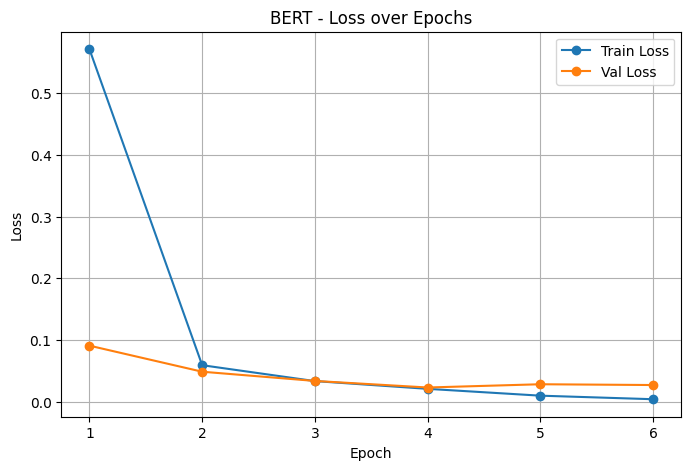

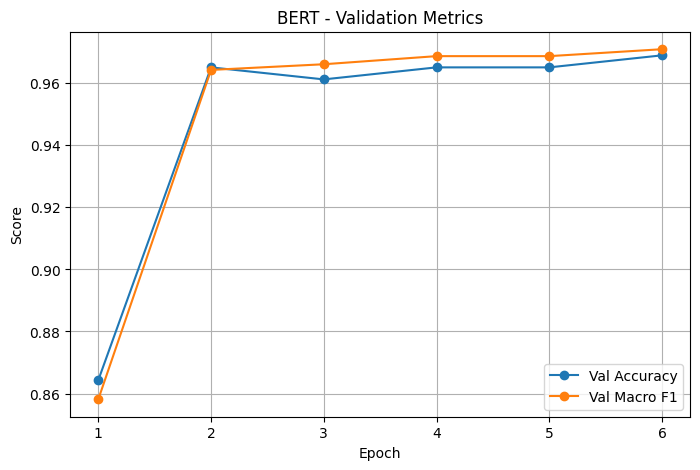

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name="BERT"):
    first = history[0]

    # Case 1: list of dicts
    if isinstance(first, dict):
        print("Detected: list of dicts")
        print("Keys in first item:", first.keys())

        # try common key names
        def pick(d, names):
            for n in names:
                if n in d:
                    return d[n]
            return None

        train_loss = [pick(x, ["train_loss", "loss", "training_loss"]) for x in history]
        val_loss   = [pick(x, ["val_loss", "valid_loss", "validation_loss"]) for x in history]
        val_acc    = [pick(x, ["val_acc", "val_accuracy", "accuracy"]) for x in history]
        val_f1     = [pick(x, ["val_macro_f1", "macro_f1", "f1"]) for x in history]

    # Case 2: list of tuples/lists
    elif isinstance(first, (tuple, list)):
        print("Detected: list of tuples/lists")
        print("First item length:", len(first))

        train_loss = [x[0] for x in history] if len(first) > 0 else None
        val_loss   = [x[1] for x in history] if len(first) > 1 else None
        val_acc    = [x[2] for x in history] if len(first) > 2 else None
        val_f1     = [x[3] for x in history] if len(first) > 3 else None

    else:
        raise ValueError(f"Unsupported history format: {type(first)}")

    epochs = range(1, len(history) + 1)

    # Loss plot
    if train_loss is not None or val_loss is not None:
        plt.figure(figsize=(8, 5))
        if train_loss is not None and any(v is not None for v in train_loss):
            plt.plot(epochs, train_loss, marker="o", label="Train Loss")
        if val_loss is not None and any(v is not None for v in val_loss):
            plt.plot(epochs, val_loss, marker="o", label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{model_name} - Loss over Epochs")
        plt.legend()
        plt.grid(True)
        plt.show()

    # Metric plot
    if val_acc is not None or val_f1 is not None:
        plt.figure(figsize=(8, 5))
        if val_acc is not None and any(v is not None for v in val_acc):
            plt.plot(epochs, val_acc, marker="o", label="Val Accuracy")
        if val_f1 is not None and any(v is not None for v in val_f1):
            plt.plot(epochs, val_f1, marker="o", label="Val Macro F1")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.title(f"{model_name} - Validation Metrics")
        plt.legend()
        plt.grid(True)
        plt.show()

plot_training_history(bert_history, model_name="BERT")

## Section 3 — BERT Evaluation
✅ *Re-run anytime.*

In [10]:
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model     = BertForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=NUM_CLASSES)
ckpt = torch.load(BERT_CKPT, map_location=device, weights_only=False)
bert_model.load_state_dict(ckpt['model_state_dict'])
bert_model.to(device)
print(f"BERT checkpoint loaded — val_acc={ckpt['val_accuracy']:.4f} | val_macro_f1={ckpt.get('val_macro_f1', float('nan')):.4f} | cf_recall={ckpt['cf_recall']:.4f}")

_, _, test_loader_bert = make_loaders(bert_tokenizer, MAX_LENGTH, BATCH_SIZE)

bert_preds, bert_trues, bert_logits = full_evaluation(
    bert_model,
    test_loader_bert,
    device,
    "BERT Baseline",
    return_logits=True
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT checkpoint loaded — val_acc=0.9729 | val_macro_f1=0.9728 | cf_recall=1.0000

BERT Baseline — TEST SET RESULTS
                  precision    recall  f1-score   support

Income Statement     0.9836    0.9375    0.9600        64
  Balance Sheets     0.9821    0.9821    0.9821        56
       Cash Flow     0.8750    1.0000    0.9333         7
           Notes     0.9315    0.9645    0.9477       141
          Others     0.9672    0.9555    0.9613       247

        accuracy                         0.9592       515
       macro avg     0.9479    0.9679    0.9569       515
    weighted avg     0.9598    0.9592    0.9593       515

CONFUSION MATRIX
[[ 60   0   0   0   4]
 [  0  55   0   1   0]
 [  0   0   7   0   0]
 [  0   1   0 136   4]
 [  1   0   1   9 236]]


## Section 4A — FinBERT + Augmentation (Standard Fine-tuning)
*Variant A: Standard BertForSequenceClassification — [CLS] pooling, all layers updated.*  
*Skip if `finbert_aug.pt` exists in Drive.*


In [ ]:
if os.path.exists(FINBERT_AUG_CKPT):
    print(f"Checkpoint found at {FINBERT_AUG_CKPT} — skip to Section 5.")
else:
    print(f"Training FinBERT Variant A — Standard fine-tuning")
    print(f"  All layers trainable | [CLS] pooling | epochs={FINBERT_EPOCHS} | lr={FINBERT_LR}")


Checkpoint found at /content/drive/MyDrive/checkpoints/finbert_aug.pt — skip to Section 5.


In [ ]:
# ── VARIANT A TRAINING ────────────────────────────────────────
finbert_tokenizer = BertTokenizer.from_pretrained(FINBERT_MODEL_NAME)
finbert_model_a   = BertForSequenceClassification.from_pretrained(
    FINBERT_MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)

train_loader, val_loader, _ = make_loaders(finbert_tokenizer, MAX_LENGTH, BATCH_SIZE)
print(f"Batches — Train:{len(train_loader)} Val:{len(val_loader)}")

finbert_model_a, _ = train_model(finbert_model_a, train_loader, val_loader, device,
                                  epochs=FINBERT_EPOCHS, lr=FINBERT_LR,
                                  class_weights=class_weights, save_path=FINBERT_AUG_CKPT)
print(f"Variant A training complete. Saved to {FINBERT_AUG_CKPT}")


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

...

  Train Loss: 0.0300 | Val Loss: 0.0702 | Val Acc: 0.9225 | Val Macro F1: 0.9464 | CF Recall: 1.0000
  ✓ Saved checkpoint at epoch 4 (val_macro_f1=0.9464, val_acc=0.9225, cf_recall=1.0000)


Epoch 5/6: 100%|██████████| 494/494 [04:01<00:00,  2.05it/s]


  Train Loss: 0.0175 | Val Loss: 0.0714 | Val Acc: 0.9380 | Val Macro F1: 0.9523 | CF Recall: 1.0000
  ✓ Saved checkpoint at epoch 5 (val_macro_f1=0.9523, val_acc=0.9380, cf_recall=1.0000)


Epoch 6/6: 100%|██████████| 494/494 [04:01<00:00,  2.05it/s]


  Train Loss: 0.0108 | Val Loss: 0.0661 | Val Acc: 0.9341 | Val Macro F1: 0.9496 | CF Recall: 1.0000
Training complete.
Best checkpoint criterion (macro_f1, acc, cf_recall): (0.9523203613429176, np.float64(0.937984496124031), np.float64(1.0))
Variant A training complete. Saved to /content/drive/MyDrive/checkpoints/finbert_aug.pt


## Section 4B — FinBERT + Augmentation + Layer Unfreezing
*Variant B: Freeze layers 0–7, train only layers 8–11 + pooler + classifier.*  
*Preserves pre-trained financial knowledge in lower layers.*  
*Skip if `finbert_unfreeze.pt` exists in Drive.*


In [ ]:
if os.path.exists(FINBERT_UNFREEZE_CKPT):
    print(f"Checkpoint found at {FINBERT_UNFREEZE_CKPT} — skip to Section 5.")
else:
    print(f"Training FinBERT Variant B — Layer unfreezing")
    print(f"  Frozen layers: 0–7 | Trainable: {UNFREEZE_LAYERS} + pooler + classifier")


Checkpoint found at /content/drive/MyDrive/checkpoints/finbert_unfreeze.pt — skip to Section 5.


In [ ]:
# ── VARIANT B TRAINING ────────────────────────────────────────
finbert_tokenizer = BertTokenizer.from_pretrained(FINBERT_MODEL_NAME)
finbert_model_b   = BertForSequenceClassification.from_pretrained(
    FINBERT_MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)

# Apply layer unfreezing
finbert_model_b = apply_layer_unfreezing(finbert_model_b, UNFREEZE_LAYERS)

train_loader, val_loader, _ = make_loaders(finbert_tokenizer, MAX_LENGTH, BATCH_SIZE)
print(f"Batches — Train:{len(train_loader)} Val:{len(val_loader)}")

finbert_model_b, _ = train_model(finbert_model_b, train_loader, val_loader, device,
                                  epochs=FINBERT_EPOCHS, lr=FINBERT_LR,
                                  class_weights=class_weights, save_path=FINBERT_UNFREEZE_CKPT)
print(f"Variant B training complete. Saved to {FINBERT_UNFREEZE_CKPT}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

  Train Loss: 0.0480 | Val Loss: 0.0761 | Val Acc: 0.8992 | Val Macro F1: 0.9223 | CF Recall: 1.0000


Epoch 5/6: 100%|██████████| 494/494 [01:55<00:00,  4.28it/s]


  Train Loss: 0.0379 | Val Loss: 0.0529 | Val Acc: 0.9302 | Val Macro F1: 0.9520 | CF Recall: 1.0000
  ✓ Saved checkpoint at epoch 5 (val_macro_f1=0.9520, val_acc=0.9302, cf_recall=1.0000)


Epoch 6/6: 100%|██████████| 494/494 [01:56<00:00,  4.26it/s]


  Train Loss: 0.0267 | Val Loss: 0.0487 | Val Acc: 0.9264 | Val Macro F1: 0.9480 | CF Recall: 1.0000
Training complete.
Best checkpoint criterion (macro_f1, acc, cf_recall): (0.9520474641711403, np.float64(0.9302325581395349), np.float64(1.0))
Variant B training complete. Saved to /content/drive/MyDrive/checkpoints/finbert_unfreeze.pt


## Section 4C — FinBERT + Augmentation + Attention Pooling
*Variant C: Mean-pool all 512 token outputs instead of [CLS] only.*  
*Rationale: financial HTML classification signals distributed across [TABLE], [HEADER] tokens.*  
*Skip if `finbert_pool.pt` exists in Drive.*


In [ ]:
if os.path.exists(FINBERT_POOL_CKPT):
    print(f"Checkpoint found at {FINBERT_POOL_CKPT} — skip to Section 5.")
else:
    print(f"Training FinBERT Variant C — Masked mean pooling")
    print(f"  Mean pool across all non-padding tokens | all layers trainable")


Training FinBERT Variant C — Masked mean pooling
  Mean pool across all non-padding tokens | all layers trainable


In [ ]:
# ── VARIANT C TRAINING ────────────────────────────────────────
finbert_tokenizer = BertTokenizer.from_pretrained(FINBERT_MODEL_NAME)
finbert_model_c   = FinBERTWithMeanPooling(
    model_name=FINBERT_MODEL_NAME, num_labels=NUM_CLASSES)

train_loader, val_loader, _ = make_loaders(finbert_tokenizer, MAX_LENGTH, BATCH_SIZE)
print(f"Batches — Train:{len(train_loader)} Val:{len(val_loader)}")

finbert_model_c, _ = train_model(finbert_model_c, train_loader, val_loader, device,
                                  epochs=FINBERT_EPOCHS, lr=FINBERT_LR,
                                  class_weights=class_weights, save_path=FINBERT_POOL_CKPT)
print(f"Variant C training complete. Saved to {FINBERT_POOL_CKPT}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches — Train:494 Val:65


Epoch 1/6: 100%|██████████| 494/494 [03:39<00:00,  2.25it/s]


  Train Loss: 0.5323 | Val Loss: 0.1039 | Val Acc: 0.7636 | Val Macro F1: 0.8537 | CF Recall: 1.0000
  ✓ Saved checkpoint at epoch 1 (val_macro_f1=0.8537, val_acc=0.7636, cf_recall=1.0000)


...

  Train Loss: 0.0311 | Val Loss: 0.0432 | Val Acc: 0.9302 | Val Macro F1: 0.9565 | CF Recall: 1.0000
  ✓ Saved checkpoint at epoch 4 (val_macro_f1=0.9565, val_acc=0.9302, cf_recall=1.0000)


Epoch 5/6: 100%|██████████| 494/494 [03:39<00:00,  2.25it/s]


  Train Loss: 0.0125 | Val Loss: 0.0584 | Val Acc: 0.9380 | Val Macro F1: 0.9600 | CF Recall: 1.0000
  ✓ Saved checkpoint at epoch 5 (val_macro_f1=0.9600, val_acc=0.9380, cf_recall=1.0000)


Epoch 6/6: 100%|██████████| 494/494 [03:39<00:00,  2.25it/s]


  Train Loss: 0.0085 | Val Loss: 0.0462 | Val Acc: 0.9341 | Val Macro F1: 0.9548 | CF Recall: 1.0000
Training complete.
Best checkpoint criterion (macro_f1, acc, cf_recall): (0.9600299769030419, np.float64(0.937984496124031), np.float64(1.0))
Variant C training complete. Saved to /content/drive/MyDrive/checkpoints/finbert_pool.pt


## Section 5 — FinBERT Evaluations
✅ *Re-run anytime — loads each checkpoint, never retrains.*

In [11]:
finbert_tokenizer = BertTokenizer.from_pretrained(FINBERT_MODEL_NAME)
_, _, test_loader_finbert = make_loaders(finbert_tokenizer, MAX_LENGTH, BATCH_SIZE)

# ── Variant A ─────────────────────────────────────────────────
print("Loading Variant A — Standard FinBERT + Aug...")
finbert_model_a = BertForSequenceClassification.from_pretrained(
    FINBERT_MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)
ckpt_a = torch.load(FINBERT_AUG_CKPT, map_location=device, weights_only=False)
finbert_model_a.load_state_dict(ckpt_a['model_state_dict'])
finbert_model_a.to(device)

print(f"  val_acc={ckpt_a['val_accuracy']:.4f} | val_macro_f1={ckpt_a.get('val_macro_f1', float('nan')):.4f} | cf_recall={ckpt_a['cf_recall']:.4f}")

finbert_preds_a, finbert_trues_a, finbert_logits_a = full_evaluation(
    finbert_model_a,
    test_loader_finbert,
    device,
    "FinBERT Variant A — Standard",
    return_logits=True
)


Loading Variant A — Standard FinBERT + Aug...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

  val_acc=0.9380 | val_macro_f1=0.9523 | cf_recall=1.0000

FinBERT Variant A — Standard — TEST SET RESULTS
                  precision    recall  f1-score   support

Income Statement     0.9661    0.8906    0.9268        64
  Balance Sheets     0.9821    0.9821    0.9821        56
       Cash Flow     1.0000    1.0000    1.0000         7
           Notes     0.9247    0.9574    0.9408       141
          Others     0.9433    0.9433    0.9433       247

        accuracy                         0.9456       515
       macro avg     0.9632    0.9547    0.9586       515
    weighted avg     0.9460    0.9456    0.9456       515

CONFUSION MATRIX
[[ 57   0   0   0   7]
 [  0  55   0   0   1]
 [  0   0   7   0   0]
 [  0   0   0 135   6]
 [  2   1   0  11 233]]


In [12]:
# ── Variant B ─────────────────────────────────────────────────
print("Loading Variant B — FinBERT + Aug + Layer Unfreezing...")
finbert_model_b = BertForSequenceClassification.from_pretrained(
    FINBERT_MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)
ckpt_b = torch.load(FINBERT_UNFREEZE_CKPT, map_location=device, weights_only=False)
finbert_model_b.load_state_dict(ckpt_b['model_state_dict'])
finbert_model_b.to(device)
print(f"  val_acc={ckpt_b['val_accuracy']:.4f} | val_macro_f1={ckpt_b.get('val_macro_f1', float('nan')):.4f} | cf_recall={ckpt_b['cf_recall']:.4f}")

_, _, test_loader_b = make_loaders(finbert_tokenizer, MAX_LENGTH, BATCH_SIZE)

finbert_preds_b, finbert_trues_b, finbert_logits_b = full_evaluation(
    finbert_model_b,
    test_loader_finbert,
    device,
    "FinBERT Variant B — Unfreeze",
    return_logits=True
)


Loading Variant B — FinBERT + Aug + Layer Unfreezing...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

  val_acc=0.9302 | val_macro_f1=0.9520 | cf_recall=1.0000

FinBERT Variant B — Unfreeze — TEST SET RESULTS
                  precision    recall  f1-score   support

Income Statement     0.9231    0.9375    0.9302        64
  Balance Sheets     0.9818    0.9643    0.9730        56
       Cash Flow     0.8750    1.0000    0.9333         7
           Notes     0.9362    0.9362    0.9362       141
          Others     0.9431    0.9393    0.9412       247

        accuracy                         0.9417       515
       macro avg     0.9318    0.9554    0.9428       515
    weighted avg     0.9420    0.9417    0.9418       515

CONFUSION MATRIX
[[ 60   0   0   0   4]
 [  0  54   0   0   2]
 [  0   0   7   0   0]
 [  0   0   1 132   8]
 [  5   1   0   9 232]]


In [13]:
# ── Variant C ─────────────────────────────────────────────────
print("Loading Variant C — FinBERT + Masked Mean Pooling...")
finbert_model_c = FinBERTWithMeanPooling(
    model_name=FINBERT_MODEL_NAME, num_labels=NUM_CLASSES)
ckpt_c = torch.load(FINBERT_POOL_CKPT, map_location=device, weights_only=False)
finbert_model_c.load_state_dict(ckpt_c['model_state_dict'])
finbert_model_c.to(device)
print(f"  val_acc={ckpt_c['val_accuracy']:.4f} | val_macro_f1={ckpt_c.get('val_macro_f1', float('nan')):.4f} | cf_recall={ckpt_c['cf_recall']:.4f}")

_, _, test_loader_c = make_loaders(finbert_tokenizer, MAX_LENGTH, BATCH_SIZE)

finbert_preds_c, finbert_trues_c, finbert_logits_c = full_evaluation(
    finbert_model_c,
    test_loader_finbert,
    device,
    "FinBERT Variant C — Mean Pool",
    return_logits=True
)


Loading Variant C — FinBERT + Masked Mean Pooling...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  val_acc=0.9380 | val_macro_f1=0.9600 | cf_recall=1.0000

FinBERT Variant C — Mean Pool — TEST SET RESULTS
                  precision    recall  f1-score   support

Income Statement     1.0000    0.8906    0.9421        64
  Balance Sheets     0.9649    0.9821    0.9735        56
       Cash Flow     1.0000    1.0000    1.0000         7
           Notes     0.9580    0.9716    0.9648       141
          Others     0.9522    0.9676    0.9598       247

        accuracy                         0.9612       515
       macro avg     0.9750    0.9624    0.9680       515
    weighted avg     0.9618    0.9612    0.9610       515

CONFUSION MATRIX
[[ 57   0   0   0   7]
 [  0  55   0   0   1]
 [  0   0   7   0   0]
 [  0   0   0 137   4]
 [  0   2   0   6 239]]


## Section 6 — Full Comparison
✅ *Re-run anytime.*

In [14]:
# ── Compute F1 for all models ─────────────────────────────────

bert_f1   = f1_score(bert_trues,      bert_preds,      average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
fin_f1_a  = f1_score(finbert_trues_a, finbert_preds_a, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
fin_f1_b  = f1_score(finbert_trues_b, finbert_preds_b, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
fin_f1_c  = f1_score(finbert_trues_c, finbert_preds_c, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)

bert_acc  = np.mean(np.array(bert_preds)      == np.array(bert_trues))
acc_a     = np.mean(np.array(finbert_preds_a) == np.array(finbert_trues_a))
acc_b     = np.mean(np.array(finbert_preds_b) == np.array(finbert_trues_b))
acc_c     = np.mean(np.array(finbert_preds_c) == np.array(finbert_trues_c))

# ── Print comparison table ────────────────────────────────────
W = 90
print("="*W)
print(f"ABLATION STUDY — All Models (Leakage-safe split, train-only augmentation, CF train target={TARGET_CF})")
print("="*W)
print(f"{'Class':<20} {'BERT':>8} {'FinBERT-A':>10} {'FinBERT-B':>10} {'FinBERT-C':>10}  Best")
print(f"{'':20} {'(baseline)':>8} {'(standard)':>10} {'(unfreeze)':>10} {'(mean pool)':>10}")
print("-"*W)
for i, name in enumerate(LABEL_NAMES):
    vals   = [bert_f1[i], fin_f1_a[i], fin_f1_b[i], fin_f1_c[i]]
    labels = ['BERT', 'Fin-A', 'Fin-B', 'Fin-C']
    best   = labels[int(np.argmax(vals))]
    print(f"  {name:<18} {bert_f1[i]*100:>7.1f}% {fin_f1_a[i]*100:>9.1f}% {fin_f1_b[i]*100:>9.1f}% {fin_f1_c[i]*100:>9.1f}%  {best}")
print("-"*W)
accs = [bert_acc, acc_a, acc_b, acc_c]
best_acc = ['BERT','Fin-A','Fin-B','Fin-C'][int(np.argmax(accs))]
print(f"  {'Overall Accuracy':<18} {bert_acc*100:>7.1f}% {acc_a*100:>9.1f}% {acc_b*100:>9.1f}% {acc_c*100:>9.1f}%  {best_acc}")
print("="*W)
print()
print("LEGEND:")
print("  FinBERT-A: Standard fine-tuning — [CLS] pooling, all 12 layers updated")
print("  FinBERT-B: Layer unfreezing — layers 0–7 frozen, 8–11 + head trainable")
print("  FinBERT-C: Masked mean pooling — mean pool across non-padding tokens")
print()
best_overall = ['BERT','FinBERT-A','FinBERT-B','FinBERT-C'][int(np.argmax(accs))]
print(f"Best overall accuracy: {best_overall} ({max(accs)*100:.1f}%)")


ABLATION STUDY — All Models (Leakage-safe split, train-only augmentation, CF train target=200)
Class                    BERT  FinBERT-A  FinBERT-B  FinBERT-C  Best
                     (baseline) (standard) (unfreeze) (mean pool)
------------------------------------------------------------------------------------------
  Income Statement      96.0%      92.7%      93.0%      94.2%  BERT
  Balance Sheets        98.2%      98.2%      97.3%      97.3%  BERT
  Cash Flow             93.3%     100.0%      93.3%     100.0%  Fin-A
  Notes                 94.8%      94.1%      93.6%      96.5%  Fin-C
  Others                96.1%      94.3%      94.1%      96.0%  BERT
------------------------------------------------------------------------------------------
  Overall Accuracy      95.9%      94.6%      94.2%      96.1%  Fin-C

LEGEND:
  FinBERT-A: Standard fine-tuning — [CLS] pooling, all 12 layers updated
  FinBERT-B: Layer unfreezing — layers 0–7 frozen, 8–11 + head trainable
  FinBERT-C: Mas

In [19]:
# Derive confidence scores from already-computed bert_logits
bert_conf = [float(np.max(torch.softmax(torch.tensor(l), dim=-1).numpy())) for l in bert_logits]
MIN_WORDS = {'Income Statement': 150, 'Balance Sheets': 80, 'Cash Flow': 80}
CRITICAL_TERMS = {
    'Income Statement': {'required': ['profit', 'income', 'tax', 'expenses'], 'expected': ['revenue']},
    'Balance Sheets':   {'required': ['current', 'assets', 'liabilities', 'equity'], 'expected': ['borrowings']},
    'Cash Flow':        {'required': ['cash', 'net', 'operating'], 'expected': ['investing', 'financing']},
}

# ─────────────────────────────────────────────────────────────
# Completeness Function (embedded)
# ─────────────────────────────────────────────────────────────
def check_completeness(text, predicted_class, logits):
    if predicted_class not in CRITICAL_TERMS:
        return 1.0, False, "N/A"

    tl = text.lower()
    issues = []
    wc = len(tl.split())

    # ensure tensor
    if isinstance(logits, np.ndarray):
        logits = torch.tensor(logits)

    probs = torch.softmax(logits, dim=-1)
    conf = probs.max().item()

    # rules
    if conf < 0.90:
        issues.append(f"low confidence ({conf:.0%})")

    if wc < MIN_WORDS[predicted_class]:
        issues.append(f"too short ({wc} words)")

    req = CRITICAL_TERMS[predicted_class]['required']
    missing = [t for t in req if t not in tl]

    if missing:
        issues.append(f"missing: {', '.join(missing)}")

    score = conf
    if wc < MIN_WORDS[predicted_class]:
        score *= 0.5
    if missing:
        score *= 0.4

    return round(min(max(score, 0), 1), 2), len(issues) > 0, (
        "Complete" if not issues else " | ".join(issues)
    )


# ─────────────────────────────────────────────────────────────
# Error Analysis + Rule Attribution
# ─────────────────────────────────────────────────────────────
id2label = {i: name for i, name in enumerate(LABEL_NAMES)}

wrong_rows = []

for i, rec in enumerate(test_records):
    true_name = rec["label_name"]
    pred_name = id2label[bert_preds[i]]
    conf = bert_conf[i]
    text = rec["text"]

    # skip Notes / Others
    if true_name in ["Notes", "Others"]:
        continue

    # only wrong predictions
    if true_name != pred_name:

        # logits handling
        logits = bert_logits[i]
        if isinstance(logits, np.ndarray):
            logits_tensor = torch.tensor(logits)
        else:
            logits_tensor = logits

        probs = torch.softmax(logits_tensor, dim=-1).numpy()
        sorted_probs = np.sort(probs)[::-1]
        margin = float(sorted_probs[0] - sorted_probs[1]) if len(sorted_probs) > 1 else float(sorted_probs[0])

        # ---- RULES ----
        low_conf = conf < 0.90
        income_guard = (pred_name == "Others") and is_income_like(text)

        comp_score, comp_flag, comp_reason = check_completeness(
            text, pred_name, logits_tensor
        )

        # final decision
        flag_review = low_conf or income_guard or comp_flag

        # WHY flagged
        reasons = []
        if low_conf:
            reasons.append("Low Confidence")
        if income_guard:
            reasons.append("Income Rule")
        if comp_flag:
            reasons.append("Incomplete")

        wrong_rows.append({
            "doc_id": rec.get("doc_id"),
            "true_label": true_name,
            "pred_label": pred_name,

            "confidence": round(conf, 3),
            "margin": round(margin, 3),

            "low_conf": low_conf,
            "income_guard": income_guard,
            "completeness_flag": comp_flag,

            "completeness_reason": comp_reason,

            "flag_review": flag_review,
            "flag_reason": " | ".join(reasons)
        })

wrong_df = pd.DataFrame(wrong_rows)

# ─────────────────────────────────────────────────────────────
# Output
# ─────────────────────────────────────────────────────────────
print(f"\nTotal wrong (excluding Notes/Others): {len(wrong_df)}")
print("="*90)
print(wrong_df)

print("\nSUMMARY")
print("="*90)
print(wrong_df["flag_reason"].value_counts())


Total wrong (excluding Notes/Others): 5
                              doc_id        true_label pred_label  confidence  \
0  Income Statement/18537020_11.html  Income Statement     Others       0.829   
1  Income Statement/18526534_11.html  Income Statement     Others       0.888   
2   Income Statement/18512677_3.html  Income Statement     Others       0.899   
3  Income Statement/18460658_20.html  Income Statement     Others       0.729   
4    Balance Sheets/18889406_12.html    Balance Sheets      Notes       0.476   

   margin  low_conf  income_guard  completeness_flag completeness_reason  \
0   0.719      True         False              False                 N/A   
1   0.851      True          True              False                 N/A   
2   0.845      True          True              False                 N/A   
3   0.506      True          True              False                 N/A   
4   0.011      True         False              False                 N/A   

   flag_review 

## Section 7 — KPI Extraction Engine
✅ *Re-run anytime — no model needed.*

In [ ]:
def parse_number(text):
    if not text: return None
    text = str(text).strip()
    neg  = text.startswith('(') and text.endswith(')')
    text = re.sub(r'[()$£€\s]', '', text)
    text = re.sub(r'Rs\.?', '', text, flags=re.IGNORECASE)
    text = text.replace(',', '')
    try: val = float(text); return -val if neg else val
    except: return None

def find_number(text, start, window=300):
    m = re.search(r'\([\d,]+\.?\d*\)|[\d,]+\.?\d+', text[start:start+window])
    return parse_number(m.group()) if m else None

def extract_income_statement(html):
    text, m = BeautifulSoup(html,'html.parser').get_text(separator='\n',strip=True), {}
    for field, pats in {
        'revenue':           [r'Revenue from [Oo]perations', r'Net [Rr]evenue', r'Net [Ss]ales'],
        'total_income':      [r'Total Income', r'Total [Rr]evenues'],
        'profit_before_tax': [r'Profit before Tax', r'Income [Bb]efore.*?[Tt]ax'],
        'net_income':        [r'Net [Pp]rofit after [Tt]ax', r'Net [Ii]ncome', r'Profit [Aa]fter [Tt]ax'],
        'eps':               [r'Earnings per [Ss]hare.*?(?:[Bb]asic|[Dd]iluted)', r'EPS'],
    }.items():
        for pat in pats:
            hit = re.search(pat, text)
            if hit: m[field] = find_number(text, hit.end()); break
        if field not in m: m[field] = None
    return m

def extract_balance_sheet(html):
    text, m = BeautifulSoup(html,'html.parser').get_text(separator='\n',strip=True), {}
    for field, pats in {
        'total_assets':        [r'TOTAL ASSETS', r'Total [Ee]quity and [Ll]iabilities'],
        'shareholders_equity': [r'TOTAL EQUITY', r'Total [Ee]quity', r"Shareholders'?\s*[Ee]quity"],
        'current_assets':      [r'Total [Cc]urrent [Aa]ssets', r'Current [Aa]ssets'],
        'current_liabilities': [r'Total [Cc]urrent [Ll]iabilities', r'Current [Ll]iabilities'],
        'total_borrowings':    [r'Total [Bb]orrowings', r'Long.?[Tt]erm [Bb]orrowings'],
    }.items():
        for pat in pats:
            hit = re.search(pat, text)
            if hit: m[field] = find_number(text, hit.end()); break
        if field not in m: m[field] = None
    a, e   = m.get('total_assets'), m.get('shareholders_equity')
    ca, cl = m.get('current_assets'), m.get('current_liabilities')
    debt   = m.get('total_borrowings')
    m['total_liabilities'] = round(a-e, 2)    if a and e            else None
    m['current_ratio']     = round(ca/cl, 2)  if ca and cl and cl   else None
    m['debt_to_equity']    = round(debt/e, 2) if debt and e         else None
    return m

def extract_cash_flow(html):
    text, m = BeautifulSoup(html,'html.parser').get_text(separator='\n',strip=True), {}
    for field, pats in {
        'operating_cf':    [r'Net cash from operating activities', r'Net cash (?:from|provided by) operating'],
        'capex':           [r'Purchase of property, plant', r'Capital [Ee]xpenditures?'],
        'financing_cf':    [r'Net cash (?:used in|from) financing activities'],
        'net_change_cash': [r'Net (?:increase|decrease).*?cash', r'Net change in cash'],
        'cash_end':        [r'Cash.*?at the end', r'Closing (?:cash|balance)'],
    }.items():
        for pat in pats:
            hit = re.search(pat, text, re.IGNORECASE)
            if hit: m[field] = find_number(text, hit.end()); break
        if field not in m: m[field] = None
    ocf, cap = m.get('operating_cf'), m.get('capex')
    m['free_cash_flow'] = round(ocf - abs(cap), 2) if ocf and cap else None
    return m

def extract_metrics(html, doc_class):
    if doc_class == 'Income Statement': return extract_income_statement(html)
    if doc_class == 'Balance Sheets':   return extract_balance_sheet(html)
    if doc_class == 'Cash Flow':        return extract_cash_flow(html)
    return {}

print("KPI extractors ready. Testing on samples...")
for label in ['Income Statement', 'Balance Sheets', 'Cash Flow']:
    folder = os.path.join(DATA_DIR, label)
    if not os.path.exists(folder): continue
    sample = os.listdir(folder)[0]
    with open(os.path.join(folder, sample), 'r', encoding='utf-8', errors='ignore') as f:
        html = f.read()
    metrics = extract_metrics(html, label)
    print(f"\n{label} — {sample}")
    print("-"*40)
    for k, v in metrics.items(): print(f"  {k:<25}: {v}")


KPI extractors ready. Testing on samples...

Income Statement — 18537020_14.html
----------------------------------------
  revenue                  : None
  total_income             : 9633.88
  profit_before_tax        : None
  net_income               : 2846.22
  eps                      : None

Balance Sheets — 18889406_3.html
----------------------------------------
  total_assets             : None
  shareholders_equity      : None
  current_assets           : 34616.0
  current_liabilities      : None
  total_borrowings         : None
  total_liabilities        : None
  current_ratio            : None
  debt_to_equity           : None

Cash Flow — 18563939_14.html
----------------------------------------
  operating_cf             : None
  capex                    : None
  financing_cf             : None
  net_change_cash          : None
  cash_end                 : None
  free_cash_flow           : None


## Section 8 — Gradio Demo
✅ *Re-run anytime — uses best FinBERT checkpoint (Variant A).*

In [ ]:
!pip install gradio -q
import gradio as gr

MIN_WORDS = {'Income Statement':150,'Balance Sheets':80,'Cash Flow':80}
CRITICAL_TERMS = {
    'Income Statement': {'required':['profit','income','tax','expenses'],'expected':['revenue']},
    'Balance Sheets':   {'required':['current','assets','liabilities','equity'],'expected':['borrowings']},
    'Cash Flow':        {'required':['cash','net','operating'],'expected':['investing','financing']},
}

def check_completeness(text, predicted_class, logits):
    if predicted_class not in CRITICAL_TERMS: return 1.0, False, "N/A"
    tl = text.lower(); issues = []
    probs = torch.softmax(logits, dim=-1); conf = probs.max().item(); wc = len(tl.split())
    if conf < 0.6:  issues.append(f"low confidence ({conf:.0%})")
    if wc < MIN_WORDS[predicted_class]: issues.append(f"too short ({wc} words)")
    req = CRITICAL_TERMS[predicted_class]['required']
    missing = [t for t in req if t not in tl]
    if missing: issues.append(f"missing: {', '.join(missing)}")
    score = conf
    if wc < MIN_WORDS[predicted_class]: score *= 0.5
    if missing: score *= 0.4
    return round(min(max(score,0),1),2), len(issues)>0, ("Complete" if not issues else " | ".join(issues))

# Load best model — Variant A (standard fine-tuning, highest accuracy)
print("Loading FinBERT Variant A for demo...")
demo_tokenizer = BertTokenizer.from_pretrained(FINBERT_MODEL_NAME)
demo_model     = BertForSequenceClassification.from_pretrained(
    FINBERT_MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)
ckpt = torch.load(FINBERT_AUG_CKPT, map_location=device, weights_only=False)
demo_model.load_state_dict(ckpt['model_state_dict'])
demo_model.to(device).eval()
print("Model ready.")

def classify_document(file):
    if file is None: return "No file uploaded","","","",""
    try:
        with open(file, 'r', encoding='utf-8', errors='ignore') as f: html = f.read()
        text = preprocess_html(html)
        enc  = demo_tokenizer(text, add_special_tokens=True, max_length=MAX_LENGTH,
                              padding='max_length', truncation=True, return_tensors='pt')
        with torch.no_grad():
            logits = demo_model(enc['input_ids'].to(device), enc['attention_mask'].to(device)).logits[0]
        probs    = torch.softmax(logits, dim=-1)
        pred_idx = torch.argmax(probs).item()
        pred_cls = LABEL_NAMES[pred_idx]
        conf     = probs[pred_idx].item()
        score, incomplete, note = check_completeness(text, pred_cls, logits)
        metrics  = extract_metrics(html, pred_cls)
        met_str  = "\n".join([f"  {k.replace('_',' ').title():<28}: {v}"
                                for k,v in metrics.items() if v is not None]) or "No metrics for this class."
        prob_str = "\n".join([f"  {LABEL_NAMES[i]:<20}: {probs[i].item():.1%}" for i in range(NUM_CLASSES)])
        status   = "⚠️ Incomplete" if incomplete else "✅ Complete"
        return pred_cls, f"{conf:.1%}", f"{status}  (Score: {score})\n{note}", met_str, prob_str
    except Exception as e: return str(e),"","","",""

with gr.Blocks(title="Financial Document Classifier") as demo:
    gr.Markdown("# Financial Document Classifier — BERT")
    gr.Markdown("Upload an HTML financial document to classify and extract key metrics.")
    with gr.Row(): file_input = gr.File(label="Upload HTML Document", file_types=[".html"])
    with gr.Row(): btn = gr.Button("Classify", variant="primary")
    with gr.Row():
        with gr.Column():
            out_class = gr.Textbox(label="Predicted Class")
            out_conf  = gr.Textbox(label="Confidence")
            out_comp  = gr.Textbox(label="Completeness", lines=3)
        with gr.Column():
            out_met   = gr.Textbox(label="Extracted Metrics", lines=10)
            out_prob  = gr.Textbox(label="All Class Probabilities", lines=7)
    btn.click(fn=classify_document, inputs=file_input,
              outputs=[out_class, out_conf, out_comp, out_met, out_prob])
demo.launch(share=True)


Loading FinBERT Variant A for demo...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

Model ready.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://74235dcc8f422d7869.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Section 9 — Visualizations & Error Analysis ✅
*Re-run anytime — all cells load from saved checkpoints, no retraining needed.*

**Cells in this section:**
- **Graph 1 (BERT Loss Curve)** — Training vs validation loss over 6 epochs
- **Graph 2 (BERT Accuracy & F1)** — Validation accuracy and macro F1 over epochs
- **Graph 3 (Confusion Matrix)** — BERT test set confusion matrix
- **Graph 4 (All Models — Val Accuracy)** — Epoch-by-epoch accuracy for all 4 models
- **Graph 5 (Per-Class F1)** — Side-by-side F1 per class across all models
- **Graph 6 (Class Distribution)** — Dataset imbalance visualization
- **Graph 7 (Model Comparison)** — Final accuracy & macro F1 summary
- **Error Analysis** — Misclassified documents flagged by confidence, completeness, and missing terms

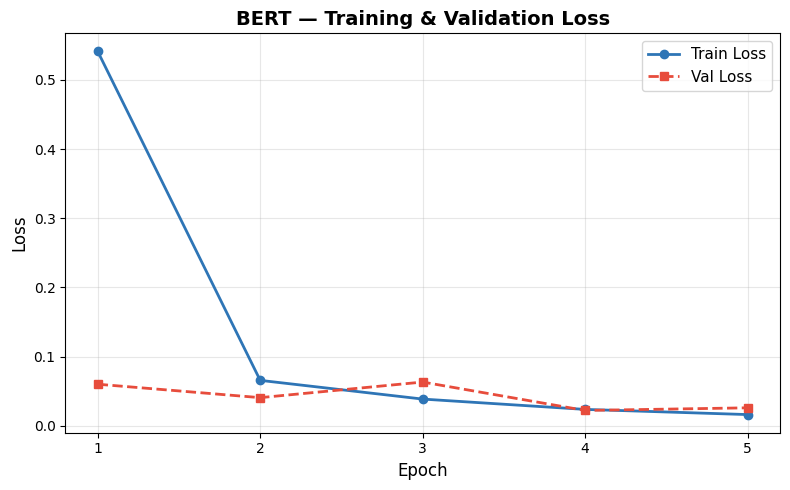

Saved: bert_loss_curve.png


In [ ]:
import matplotlib.pyplot as plt
import torch

# Load BERT checkpoint
ckpt = torch.load(BERT_CKPT, map_location='cpu', weights_only=False)
history = ckpt['history']

epochs = [h['epoch'] for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss = [h['val_loss'] for h in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'o-', color='#2E75B6', label='Train Loss', linewidth=2, markersize=6)
plt.plot(epochs, val_loss, 's--', color='#E74C3C', label='Val Loss', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('BERT — Training & Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bert_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bert_loss_curve.png")

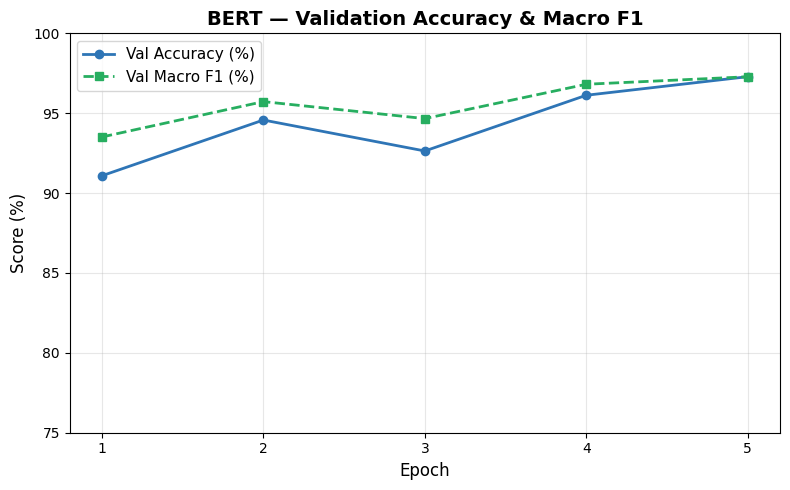

Saved: bert_acc_f1.png


In [ ]:
import matplotlib.pyplot as plt
import torch

ckpt = torch.load(BERT_CKPT, map_location='cpu', weights_only=False)
history = ckpt['history']

epochs = [h['epoch'] for h in history]
val_acc = [h['val_acc'] * 100 for h in history]
val_f1  = [h['val_macro_f1'] * 100 for h in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, val_acc, 'o-', color='#2E75B6', label='Val Accuracy (%)', linewidth=2, markersize=6)
plt.plot(epochs, val_f1,  's--', color='#27AE60', label='Val Macro F1 (%)', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Score (%)', fontsize=12)
plt.title('BERT — Validation Accuracy & Macro F1', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(epochs)
plt.ylim(75, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bert_acc_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bert_acc_f1.png")

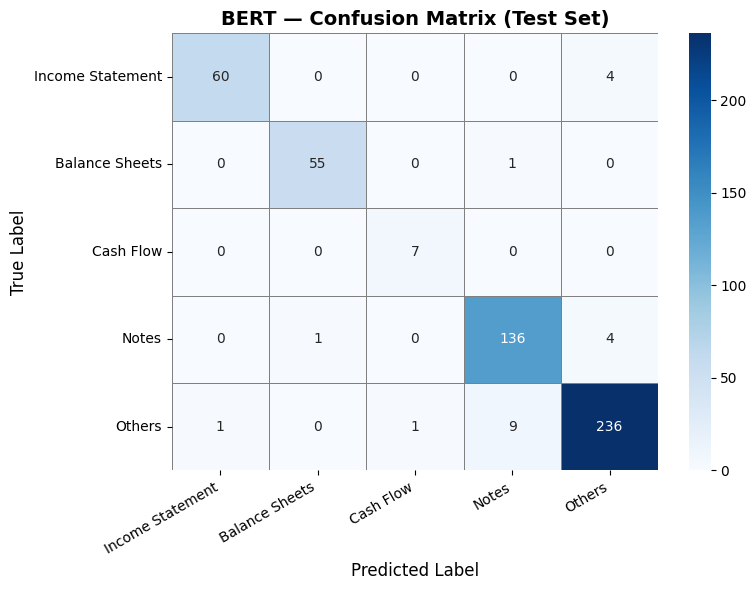

Saved: bert_confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Uses bert_preds and bert_trues from Section 3
cm = confusion_matrix(bert_trues, bert_preds, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, linecolor='gray')
plt.title('BERT — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bert_confusion_matrix.png")

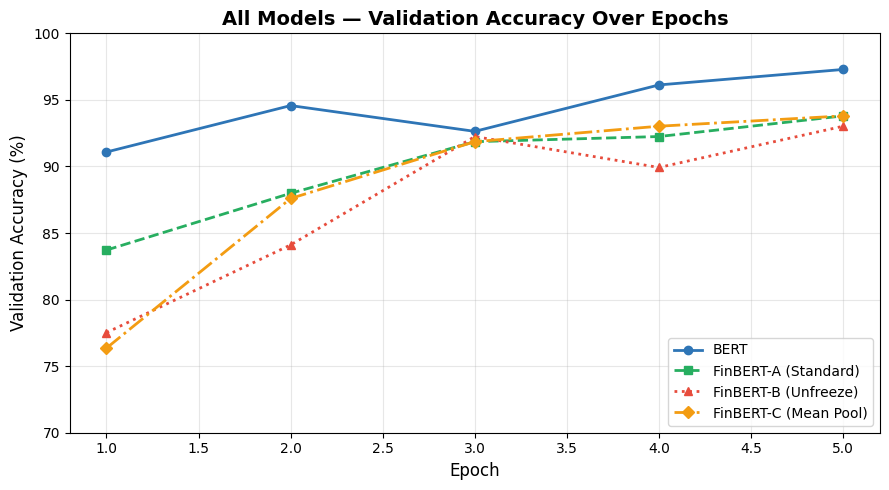

Saved: all_models_val_acc.png


In [ ]:
import matplotlib.pyplot as plt
import torch

models = {
    'BERT': BERT_CKPT,
    'FinBERT-A (Standard)': FINBERT_AUG_CKPT,
    'FinBERT-B (Unfreeze)': FINBERT_UNFREEZE_CKPT,
    'FinBERT-C (Mean Pool)': FINBERT_POOL_CKPT,
}
colors = ['#2E75B6', '#27AE60', '#E74C3C', '#F39C12']
styles = ['o-', 's--', '^:', 'D-.']

plt.figure(figsize=(9, 5))
for (name, path), color, style in zip(models.items(), colors, styles):
    ckpt = torch.load(path, map_location='cpu', weights_only=False)
    history = ckpt['history']
    epochs = [h['epoch'] for h in history]
    val_acc = [h['val_acc'] * 100 for h in history]
    plt.plot(epochs, val_acc, style, color=color, label=name, linewidth=2, markersize=6)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.title('All Models — Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='lower right')
plt.ylim(70, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_models_val_acc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_models_val_acc.png")

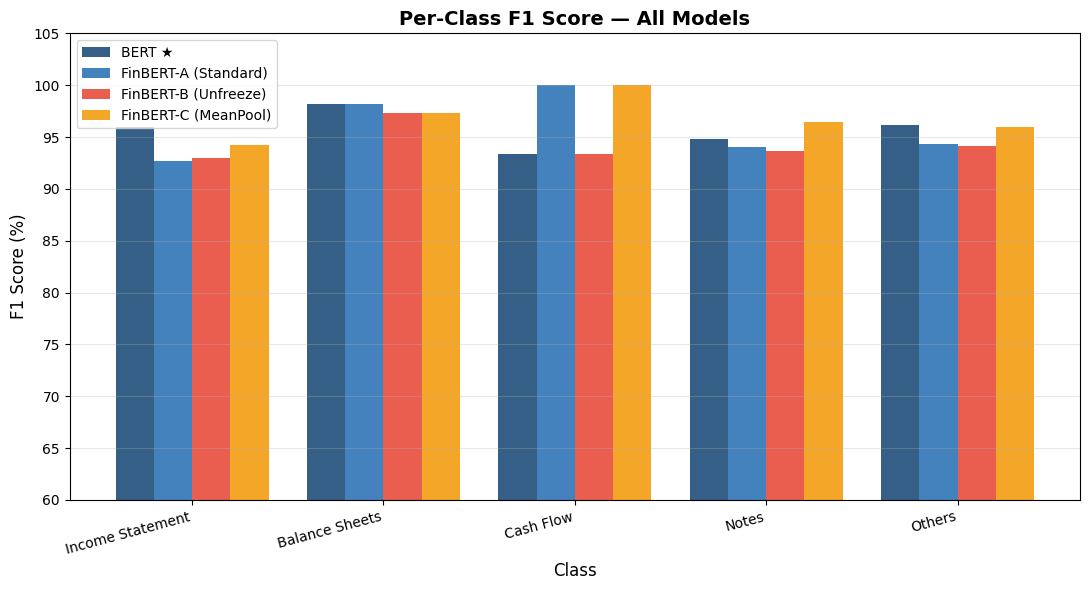

Saved: per_class_f1_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# --- Assumes bert_preds, bert_trues, finbert_preds_a/b/c, finbert_trues_a already in memory ---
# If not, re-run the reload block from Graph 3 first, then reload FinBERT variants similarly

bert_f1  = f1_score(bert_trues,      bert_preds,      average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
fin_f1_a = f1_score(finbert_trues_a, finbert_preds_a, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
fin_f1_b = f1_score(finbert_trues_b, finbert_preds_b, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
fin_f1_c = f1_score(finbert_trues_c, finbert_preds_c, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)

x = np.arange(len(LABEL_NAMES))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - 1.5*width, bert_f1  * 100, width, label='BERT ★',             color='#1F4E79', alpha=0.9)
ax.bar(x - 0.5*width, fin_f1_a * 100, width, label='FinBERT-A (Standard)',color='#2E75B6', alpha=0.9)
ax.bar(x + 0.5*width, fin_f1_b * 100, width, label='FinBERT-B (Unfreeze)',color='#E74C3C', alpha=0.9)
ax.bar(x + 1.5*width, fin_f1_c * 100, width, label='FinBERT-C (MeanPool)',color='#F39C12', alpha=0.9)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('F1 Score (%)', fontsize=12)
ax.set_title('Per-Class F1 Score — All Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, rotation=15, ha='right', fontsize=10)
ax.set_ylim(60, 105)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_class_f1_comparison.png")

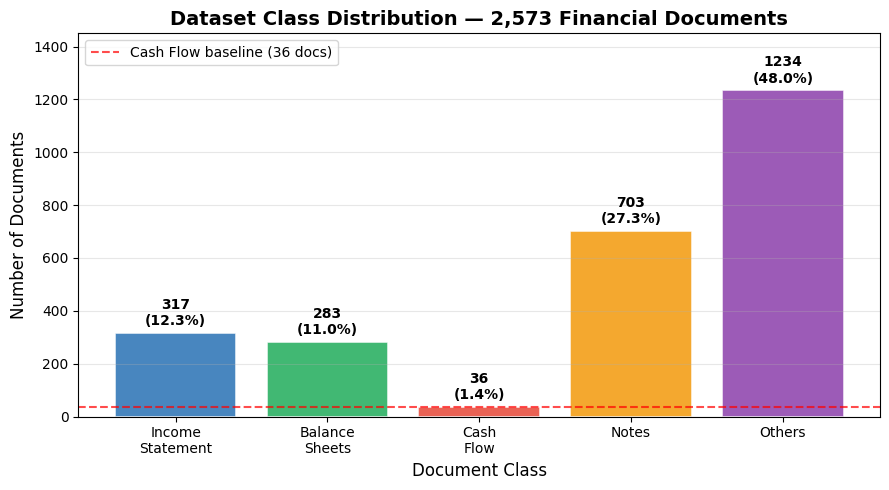

Saved: class_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['Income\nStatement', 'Balance\nSheets', 'Cash\nFlow', 'Notes', 'Others']
counts  = [317, 283, 36, 703, 1234]
colors  = ['#2E75B6', '#27AE60', '#E74C3C', '#F39C12', '#8E44AD']
total   = sum(counts)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(classes, counts, color=colors, alpha=0.88, edgecolor='white', linewidth=1.2)

for bar, count in zip(bars, counts):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 18,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Document Class', fontsize=12)
ax.set_ylabel('Number of Documents', fontsize=12)
ax.set_title('Dataset Class Distribution — 2,573 Financial Documents', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1450)
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=36, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Cash Flow baseline (36 docs)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

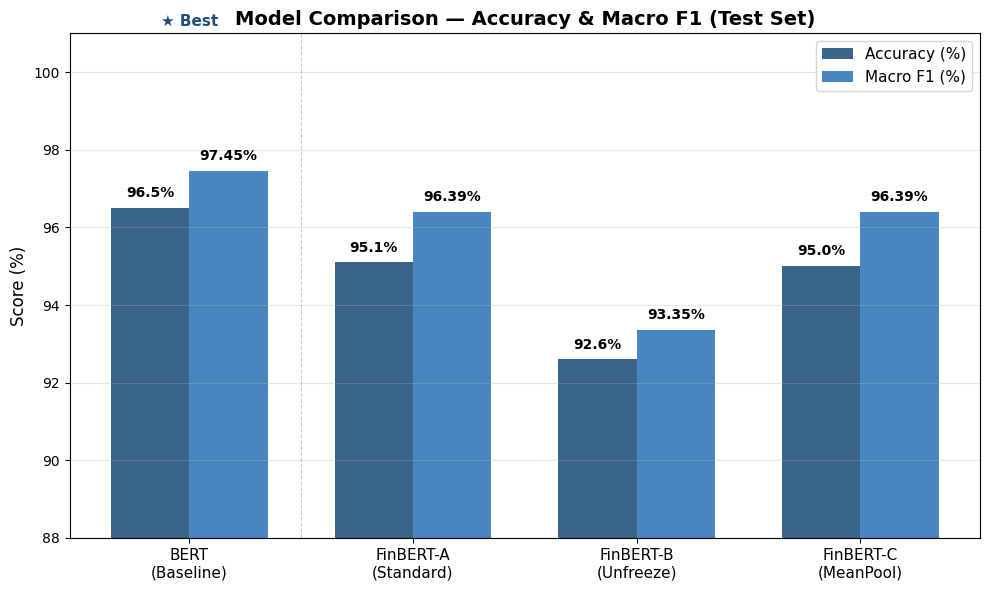

Saved: model_comparison_final.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models   = ['BERT\n(Baseline)', 'FinBERT-A\n(Standard)', 'FinBERT-B\n(Unfreeze)', 'FinBERT-C\n(MeanPool)']
accuracy = [96.5, 95.1, 92.6, 95.0]
macro_f1 = [97.45, 96.39, 93.35, 96.39]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy (%)',  color='#1F4E79', alpha=0.88)
bars2 = ax.bar(x + width/2, macro_f1, width, label='Macro F1 (%)', color='#2E75B6', alpha=0.88)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison — Accuracy & Macro F1 (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(88, 101)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# Highlight BERT as best
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)
ax.text(0, 101.2, '★ Best', ha='center', fontsize=11, color='#1F4E79', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_final.png")

In [ ]:
import pandas as pd
import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification

# --- Force full reload ---
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
_, _, test_loader_bert = make_loaders(bert_tokenizer, MAX_LENGTH, BATCH_SIZE)
bert_model = BertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)
ckpt = torch.load(BERT_CKPT, map_location=device, weights_only=False)
bert_model.load_state_dict(ckpt['model_state_dict'])
bert_model.to(device).eval()

bert_preds, bert_trues, bert_logits, bert_conf = [], [], [], []
with torch.no_grad():
    for batch in test_loader_bert:
        out = bert_model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
        probs = torch.softmax(out.logits, dim=1)
        bert_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
        bert_trues.extend(batch['labels'].numpy())
        bert_logits.extend(out.logits.cpu().numpy())
        bert_conf.extend(probs.max(dim=1).values.cpu().numpy())

print(f"Loaded: {len(bert_preds)} predictions, {len(bert_conf)} confidence scores")

# --- Rebuild wrong_df ---
id2label = {i: name for i, name in enumerate(LABEL_NAMES)}

MIN_WORDS = {'Income Statement': 150, 'Balance Sheets': 80, 'Cash Flow': 80}
CRITICAL_TERMS = {
    'Income Statement': {'required': ['profit', 'income', 'tax', 'expenses']},
    'Balance Sheets':   {'required': ['current', 'assets', 'liabilities', 'equity']},
    'Cash Flow':        {'required': ['cash', 'net', 'operating']},
}

wrong_rows = []
for i, rec in enumerate(test_records):
    true_name = rec['label_name']
    pred_name = id2label[bert_preds[i]]
    conf = bert_conf[i]
    text = rec['text']

    if true_name != pred_name:
        logits_tensor = torch.tensor(bert_logits[i])
        probs = torch.softmax(logits_tensor, dim=-1).numpy()
        sorted_probs = np.sort(probs)[::-1]
        margin = float(sorted_probs[0] - sorted_probs[1])

        low_conf = conf < 0.90
        wc = len(text.lower().split())
        short_doc = pred_name in MIN_WORDS and wc < MIN_WORDS[pred_name]
        missing = []
        if pred_name in CRITICAL_TERMS:
            missing = [t for t in CRITICAL_TERMS[pred_name]['required'] if t not in text.lower()]
        comp_flag = short_doc or len(missing) > 0

        reasons = []
        if low_conf: reasons.append('Low Confidence')
        if comp_flag: reasons.append('Incomplete/Missing Terms')

        wrong_rows.append({
            'true_label': true_name,
            'pred_label': pred_name,
            'confidence': round(conf, 3),
            'margin': round(margin, 3),
            'low_conf': low_conf,
            'completeness_flag': comp_flag,
            'missing_terms': ', '.join(missing) if missing else 'None',
            'flag_review': low_conf or comp_flag,
            'flag_reason': ' | '.join(reasons) if reasons else 'None'
        })

wrong_df = pd.DataFrame(wrong_rows)

print("\n=== WRONG PREDICTIONS SUMMARY ===")
print(f"Total misclassified: {len(wrong_df)}")
print()
print("True vs Predicted breakdown:")
print(wrong_df[['true_label','pred_label','confidence','margin','flag_reason']].to_string())
print()
print("Flag reason counts:")
print(wrong_df['flag_reason'].value_counts())
print()
print("=== CLASS WEIGHTS ===")
for i, (name, w) in enumerate(zip(LABEL_NAMES, class_weights)):
    print(f"  {name}: {w:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: 515 predictions, 515 confidence scores

=== WRONG PREDICTIONS SUMMARY ===
Total misclassified: 21

True vs Predicted breakdown:
          true_label        pred_label  confidence  margin                                flag_reason
0   Income Statement            Others       0.829   0.719                             Low Confidence
1   Income Statement            Others       0.888   0.851                             Low Confidence
2   Income Statement            Others       0.899   0.845                             Low Confidence
3             Others             Notes       0.882   0.820                             Low Confidence
4             Others             Notes       0.787   0.664                             Low Confidence
5             Others             Notes       0.683   0.401                             Low Confidence
6              Notes            Others       0.508   0.040                             Low Confidence
7             Others             Notes       0.5